<a href="https://colab.research.google.com/github/emilyrgarman/ml3finalproject_triage/blob/main/ANN_CLINICALBERT_BUILDING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##ANN + ClinicalBERT Model Building

In [34]:
! git clone https://github.com/emilyrgarman/ml3finalproject_triage.git

fatal: destination path 'ml3finalproject_triage' already exists and is not an empty directory.


In [35]:
import pandas as pd
import numpy as np
import random
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

SEED = 42

Loading in and merging train and test sets with chief complaints text data

In [36]:
tab_data = pd.read_csv('/content/ml3finalproject_triage/train.csv')
complaints = pd.read_csv('/content/ml3finalproject_triage/chief_complaints.csv')
history = pd.read_csv('/content/ml3finalproject_triage/patient_history.csv')

Stripping severity descriptions from the text data

In [37]:
SEVERITY_WORDS = ['mild', 'moderate', 'severe',
                  'critical', 'minor', 'major', 'actively',
                  'intermittent', 'in known patient']

def clean_complaint(x):
    x = re.split(r'[,，]', x)[0]
    return re.sub('|'.join(SEVERITY_WORDS), '', x, flags=re.IGNORECASE).strip()

complaints['cc_stripped'] = complaints['chief_complaint_raw'].apply(clean_complaint)
print(len(complaints))

100000


In [38]:
complaints = complaints.drop_duplicates(subset=['cc_stripped'])
print(len(complaints))

1973


In [39]:
df = tab_data.merge(complaints[['patient_id', 'cc_stripped']], on='patient_id', how='inner')
df = df.merge(history, on='patient_id', how='inner')

Preprocessing and train/validation split

In [40]:
# ── Columns ────────────────────────────────────────────────
NUMERIC_COLS = ['age', 'num_active_medications', 'num_comorbidities',
                'systolic_bp', 'diastolic_bp', 'heart_rate',
                'respiratory_rate', 'temperature_c', 'spo2',
                'gcs_total', 'pain_score', 'bmi',
                'num_prior_ed_visits_12m', 'num_prior_admissions_12m']
CATEG_COLS   = ['arrival_mode', 'sex', 'transport_origin',
                'pain_location', 'mental_status_triage']
DUMMY_COLS   = ['hx_hypertension', 'hx_diabetes_type2', 'hx_diabetes_type1',
                'hx_asthma', 'hx_copd', 'hx_heart_failure', 'hx_atrial_fibrillation',
                'hx_ckd', 'hx_liver_disease', 'hx_malignancy', 'hx_obesity',
                'hx_depression', 'hx_anxiety', 'hx_dementia', 'hx_epilepsy',
                'hx_hypothyroidism', 'hx_hyperthyroidism', 'hx_hiv', 'hx_coagulopathy',
                'hx_immunosuppressed', 'hx_pregnant', 'hx_substance_use_disorder',
                'hx_coronary_artery_disease', 'hx_stroke_prior',
                'hx_peripheral_vascular_disease']

TARGET_COL = 'triage_acuity'
TEXT_COL   = 'cc_stripped'
TABULAR_COLS = NUMERIC_COLS + CATEG_COLS + DUMMY_COLS

# ── Encode categorical columns ───────────────────────────
for col in CATEG_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# ── Tabular preprocessing ────────────────────────────────
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X_tab = scaler.fit_transform(imputer.fit_transform(df[TABULAR_COLS]))

# ── Labels ───────────────────────────────────────────────
y = df[TARGET_COL].values - 1  # shift 1–5 → 0–4 for CrossEntropyLoss

# ── Split into train, val, test ──────────────────────────
# stratify ensures class distribution is preserved
X_temp, X_test, y_temp, y_test, texts_temp, texts_test = train_test_split(
    X_tab, y, df[TEXT_COL].fillna('').values,
    test_size=0.1, random_state=42, stratify=y
)

X_tr, X_val, y_tr, y_val, texts_tr, texts_val = train_test_split(
    X_temp, y_temp, texts_temp,
    test_size=0.2, random_state=42, stratify=y_temp
)

# ── Verification ─────────────────────────────────────────
overlap_train_val = set(texts_tr) & set(texts_val)
overlap_train_test = set(texts_tr) & set(texts_test)
overlap_val_test = set(texts_val) & set(texts_test)

print(f"Train: {len(y_tr)} | Val: {len(y_val)} | Test: {len(y_test)}")
print(f"Overlap Train/Val: {len(overlap_train_val)}")
print(f"Overlap Train/Test: {len(overlap_train_test)}")
print(f"Overlap Val/Test: {len(overlap_val_test)}")

Train: 1414 | Val: 354 | Test: 197
Overlap Train/Val: 0
Overlap Train/Test: 0
Overlap Val/Test: 0


***Augmenting training data to introduce spelling errors and abbreviations***

In [41]:
# ── Clinical abbreviations ─────────────────────────────────────────
ABBREV_MAP = {
    'with': 'w/',
    'without': 'w/o',
    'history of': 'hx of',
    'complaint of': 'c/o',
    'shortness of breath': 'SOB',
    'loss of consciousness': 'LOC',
    'atrial fibrillation': 'AF',
    'diabetic ketoacidosis': 'DKA',
    'urinary tract infection': 'UTI',
    'motor vehicle accident': 'MVA',
    'chest pain': 'CP',
    'blood pressure': 'BP',
    'heart rate': 'HR',
    'nausea and vomiting': 'N&V',
    'upper respiratory tract infection': 'URTI',
    'shortness of breath': 'SOB',
    'gastrointestinal': 'GI',
    'myocardial infarction': 'MI',
    'pulmonary embolism': 'PE',
    'deep vein thrombosis': 'DVT',
    'electrocardiogram': 'ECG',
    'fracture': 'frx',
    'laceration': 'lac',
    'abdominal': 'abd',
    'bilateral': 'bil',
}

# ── Typos ──────────────────────────────────────────────────────────
TYPO_MAP = {
    'fever': ['fevre', 'fver', 'fevr'],
    'pain': ['paon', 'pian', 'pan'],
    'vomiting': ['vomitting', 'vomitng', 'vomitin'],
    'breathing': ['breathng', 'brething', 'breathin'],
    'headache': ['headach', 'headche', 'hedache'],
    'abdominal': ['abdomnal', 'abdomial', 'abdomianl'],
    'dizziness': ['dizzness', 'diziness', 'dizzines'],
    'swelling': ['sweling', 'swlling', 'sweeling'],
    'bleeding': ['bleeing', 'bleding', 'bleedin'],
    'fracture': ['fractue', 'fractrure', 'fractyre'],
    'infection': ['infecton', 'infeccion', 'infectoin'],
    'severe': ['severre', 'seveer', 'sevre'],
    'chronic': ['chronc', 'chornic', 'chonic'],
    'acute': ['acuте', 'acte', 'acut'],
    'nausea': ['nasea', 'nauseau', 'nasuea'],
    'laceration': ['laceraion', 'lacerartion', 'laceraton'],
    'palpitations': ['palpitaions', 'palpitaitons', 'palpitatons'],
    'dyspnoea': ['dyspnoea', 'dyspnea', 'dispnoea'],
    'haemorrhage': ['haemmorhage', 'heamorrhage', 'haemorrhge'],
}

def abbreviate(text, p=0.5):
    for term, abbrev in ABBREV_MAP.items():
        if term in text.lower() and random.random() < p:
            text = re.sub(term, abbrev, text, flags=re.IGNORECASE)
    return text

def add_typos(text, p=0.2):
    words = text.split()
    for i, word in enumerate(words):
        if word.lower() in TYPO_MAP and random.random() < p:
            words[i] = random.choice(TYPO_MAP[word.lower()])
    return ' '.join(words)

def augment(text):
    r = random.random()
    if r < 0.4:
        text = abbreviate(text, p=0.8)    # heavy abbreviation
    elif r < 0.7:
        text = add_typos(text, p=0.3)     # some typos
    elif r < 0.9:
        text = abbreviate(text, p=0.4)    # light abbreviation
        text = add_typos(text, p=0.1)     # plus occasional typo
    # else 10% → return text unchanged
    return text

# ── Apply to train only ────────────────────────────────────────────
aug_texts  = [augment(t) for t in texts_tr]
aug_labels = y_tr.copy()

texts_tr_aug = aug_texts.copy()
y_tr_aug     = aug_labels.copy()

ANN (tabular)

In [42]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Model definition ───────────────────────────────────────────────
class TabularANN(nn.Module):
    def __init__(self, input_dim, num_classes=5, hidden=[128, 64], dropout=0.3):
        super().__init__()
        layers = []
        in_d = input_dim
        for h in hidden:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)  # raw logits

# ── DataLoaders ────────────────────────────────────────────────────
def make_loader(X, y=None, batch_size=256, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    if y is not None:
        yt = torch.tensor(y.squeeze(), dtype=torch.long)
        return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)
    return DataLoader(TensorDataset(Xt), batch_size=batch_size)

tr_loader  = make_loader(X_tr,  y_tr,  shuffle=True)
val_loader = make_loader(X_val, y_val)

# ── Training ───────────────────────────────────────────────────────
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS  = 30

ann       = TabularANN(input_dim=X_tr.shape[1]).to(DEVICE)
optimizer = torch.optim.AdamW(ann.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss, best_state = float('inf'), None

for epoch in range(1, EPOCHS + 1):
    ann.train()
    for Xb, yb in tr_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(ann(Xb), yb)
        loss.backward()
        optimizer.step()
    scheduler.step()

    # Validation
    ann.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            logits = ann(Xb.to(DEVICE))
            val_loss += criterion(logits, yb.to(DEVICE)).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    val_loss /= len(val_loader)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = ann.state_dict()

    if epoch % 5 == 0:
        from sklearn.metrics import f1_score
        f1 = f1_score(trues, preds, average='macro')
        print(f'Epoch {epoch:3d} | Val Loss: {val_loss:.4f} | Val Macro-F1: {f1:.4f}')

ann.load_state_dict(best_state)
print('Training complete. Best val loss:', round(best_val_loss, 4))

# ── Get probabilities for fusion later ────────────────────────────
def get_probs(model, X):
    model.eval()
    loader = make_loader(X)
    probs  = []
    with torch.no_grad():
        for (Xb,) in loader:
            logits = model(Xb.to(DEVICE))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(probs)

ann_val_probs  = get_probs(ann, X_val)
ann_test_probs = get_probs(ann, X_test)

Epoch   5 | Val Loss: 1.0783 | Val Macro-F1: 0.5138
Epoch  10 | Val Loss: 0.8906 | Val Macro-F1: 0.6133
Epoch  15 | Val Loss: 0.7823 | Val Macro-F1: 0.6636
Epoch  20 | Val Loss: 0.7255 | Val Macro-F1: 0.7117
Epoch  25 | Val Loss: 0.7020 | Val Macro-F1: 0.7049
Epoch  30 | Val Loss: 0.6960 | Val Macro-F1: 0.7108
Training complete. Best val loss: 0.696


ClinicalBERT (text)

In [43]:
lengths = [len(tokenizer.encode(t, add_special_tokens=True)) for t in texts_tr_aug]

print(f'Min:    {min(lengths)}')
print(f'Max:    {max(lengths)}')

Min:    3
Max:    23


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 1.4867 | Val Loss: 1.1692 | Val Macro-F1: 0.4225
Epoch 02 | Train Loss: 0.9932 | Val Loss: 0.7469 | Val Macro-F1: 0.6890
Epoch 03 | Train Loss: 0.5880 | Val Loss: 0.3966 | Val Macro-F1: 0.8688
Epoch 04 | Train Loss: 0.3052 | Val Loss: 0.1926 | Val Macro-F1: 0.9498
Epoch 05 | Train Loss: 0.1534 | Val Loss: 0.0964 | Val Macro-F1: 0.9773
Epoch 06 | Train Loss: 0.1158 | Val Loss: 0.0749 | Val Macro-F1: 0.9781
Epoch 07 | Train Loss: 0.0834 | Val Loss: 0.0515 | Val Macro-F1: 0.9915
Epoch 08 | Train Loss: 0.0705 | Val Loss: 0.0531 | Val Macro-F1: 0.9834
           | No improvement. Patience: 1/3
Epoch 09 | Train Loss: 0.0435 | Val Loss: 0.0795 | Val Macro-F1: 0.9807
           | No improvement. Patience: 2/3
Epoch 10 | Train Loss: 0.0472 | Val Loss: 0.0279 | Val Macro-F1: 0.9915
Epoch 11 | Train Loss: 0.0241 | Val Loss: 0.0532 | Val Macro-F1: 0.9861
           | No improvement. Patience: 1/3
Epoch 12 | Train Loss: 0.0350 | Val Loss: 0.0492 | Val Macro-F1: 0.9834
       

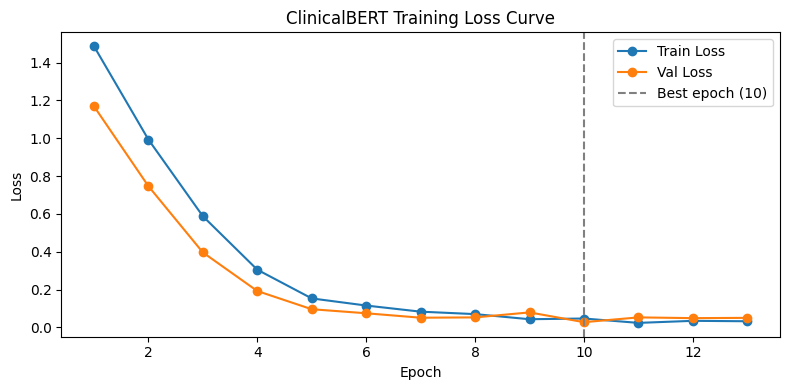

In [44]:
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt

BERT_MODEL = 'emilyalsentzer/Bio_ClinicalBERT'
MAX_LEN    = 32

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

# ── Dataset ────────────────────────────────────────────────────────
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels=None):
        self.texts  = list(texts)
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx], max_length=MAX_LEN,
                        padding='max_length', truncation=True,
                        return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ── Model ──────────────────────────────────────────────────────────
class ClinicalBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes=5, dropout=0.1):
        super().__init__()
        self.bert    = AutoModel.from_pretrained(model_name)
        hidden_size  = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.clf     = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        out     = self.bert(input_ids=input_ids,
                            attention_mask=attention_mask,
                            token_type_ids=token_type_ids)
        cls_emb = out.last_hidden_state[:, 0, :]
        logits  = self.clf(self.dropout(cls_emb))
        return logits, cls_emb

# ── DataLoaders ────────────────────────────────────────────────────
tr_text_ds  = TextDataset(texts_tr_aug, y_tr_aug.squeeze())
val_text_ds = TextDataset(texts_val, y_val.squeeze())

tr_text_loader  = DataLoader(tr_text_ds,  batch_size=64, shuffle=True)
val_text_loader = DataLoader(val_text_ds, batch_size=64)

# ── Training ───────────────────────────────────────────────────────
BERT_EPOCHS = 50
PATIENCE    = 3

bert_clf       = ClinicalBERTClassifier(BERT_MODEL).to(DEVICE)
bert_optimizer = torch.optim.AdamW(bert_clf.parameters(), lr=2e-5, weight_decay=1e-2)
class_counts = np.bincount(y_tr_aug)
weights = 1.0 / class_counts
weights = weights / weights.sum()
bert_criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE))
bert_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(bert_optimizer, T_max=BERT_EPOCHS)

best_bert_loss  = float('inf')
best_bert_state = None
patience_count  = 0
train_losses    = []
val_losses      = []

for epoch in range(1, BERT_EPOCHS + 1):
    # ── Train ──
    bert_clf.train()
    epoch_train_loss = 0
    for batch in tr_text_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)

        bert_optimizer.zero_grad()
        logits, _ = bert_clf(input_ids, attn_mask)
        loss      = bert_criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_clf.parameters(), max_norm=1.0)
        bert_optimizer.step()
        epoch_train_loss += loss.item()

    epoch_train_loss /= len(tr_text_loader)
    train_losses.append(epoch_train_loss)
    bert_scheduler.step()  # epoch-level

    # ── Validate ──
    bert_clf.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for batch in val_text_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            labels    = batch['labels'].to(DEVICE)
            logits, _ = bert_clf(input_ids, attn_mask)
            val_loss += bert_criterion(logits, labels).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(labels.cpu().numpy())

    val_loss /= len(val_text_loader)
    val_losses.append(val_loss)
    f1 = f1_score(trues, preds, average='macro')
    print(f'Epoch {epoch:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro-F1: {f1:.4f}')

    # ── Early stopping ──
    if val_loss < best_bert_loss:
        best_bert_loss  = val_loss
        best_bert_state = bert_clf.state_dict()
        patience_count  = 0
    else:
        patience_count += 1
        print(f'           | No improvement. Patience: {patience_count}/{PATIENCE}')
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

bert_clf.load_state_dict(best_bert_state)
print('Training complete. Best val loss:', round(best_bert_loss, 4))

# ── Loss curve ─────────────────────────────────────────────────────
epochs_ran = range(1, len(train_losses) + 1)
best_epoch = val_losses.index(best_bert_loss) + 1

plt.figure(figsize=(8, 4))
plt.plot(epochs_ran, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_ran, val_losses,   label='Val Loss',   marker='o')
plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ClinicalBERT Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('bert_loss_curve.png', dpi=150)
plt.show()

# ── Get probabilities and embeddings for fusion ────────────────────
def get_bert_probs_and_embeddings(model, texts, labels=None):
    model.eval()
    ds     = TextDataset(texts, labels)
    loader = DataLoader(ds, batch_size=32)
    probs, embeddings = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            logits, cls_emb = model(input_ids, attn_mask)
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            embeddings.append(cls_emb.cpu().numpy())
    return np.vstack(probs), np.vstack(embeddings)

bert_val_probs,  bert_val_embs  = get_bert_probs_and_embeddings(bert_clf, texts_val)
bert_test_probs, bert_test_embs = get_bert_probs_and_embeddings(bert_clf, texts_test)

Fusion and results across models

Epoch   5 | Val Loss: 0.0531 | Val Macro-F1: 0.9888
Epoch  10 | Val Loss: 0.0502 | Val Macro-F1: 0.9888
Epoch  15 | Val Loss: 0.0494 | Val Macro-F1: 0.9888
Epoch  20 | Val Loss: 0.0486 | Val Macro-F1: 0.9888
Best val loss: 0.0485

Results across models on test set
ANN only             Macro-F1: 0.7235
BERT only            Macro-F1: 0.9902
Late Fusion          Macro-F1: 0.9902
Early Fusion         Macro-F1: 0.9848

Cost-sensitive score (late fusion): 0.9968


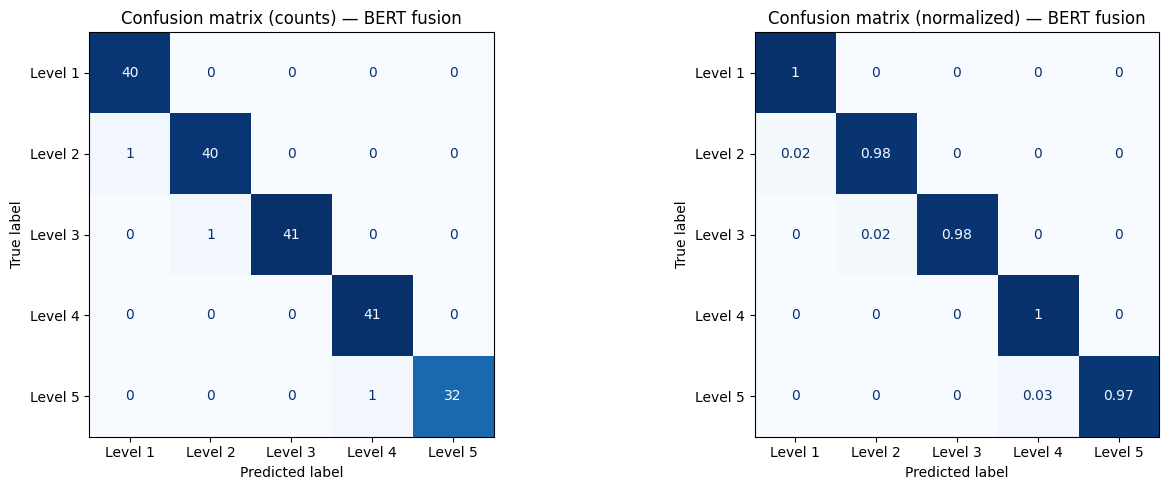

In [46]:
# Late fusion: average BERT + ANN probs
late_val_probs_bert  = (ann_val_probs + bert_val_probs) / 2
late_test_probs_bert = (ann_test_probs + bert_test_probs) / 2

late_val_preds_bert  = late_val_probs_bert.argmax(axis=1)
late_test_preds_bert = late_test_probs_bert.argmax(axis=1)

# ── Early fusion ───────────────────────────────────────────────────
# Get BERT embeddings for the non-augmented training set (for fusion)
bert_tr_probs, bert_tr_embs = get_bert_probs_and_embeddings(bert_clf, texts_tr)

early_tr_X_bert   = np.concatenate([bert_tr_embs,  X_tr],  axis=1)
early_val_X_bert  = np.concatenate([bert_val_embs,  X_val], axis=1)
early_test_X_bert = np.concatenate([bert_test_embs, X_test], axis=1)

INPUT_DIM_BERT = early_tr_X_bert.shape[1]

class EarlyFusionHead(nn.Module):
    def __init__(self, input_dim, num_classes=5, hidden=[256, 128], dropout=0.3):
        super().__init__()
        layers = []
        in_d = input_dim
        for h in hidden:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

fusion_head_bert = EarlyFusionHead(input_dim=INPUT_DIM_BERT).to(DEVICE)

ef_tr_loader_bert  = make_loader(early_tr_X_bert,  y_tr,  shuffle=True)
ef_val_loader_bert = make_loader(early_val_X_bert, y_val)

# ── Train early fusion head ────────────────────────────────────────
EPOCHS_EF_BERT = 20
optimizer_ef_bert = torch.optim.AdamW(fusion_head_bert.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_ef_bert = nn.CrossEntropyLoss()
scheduler_ef_bert = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ef_bert, T_max=EPOCHS_EF_BERT)

best_val_loss_ef_bert, best_state_ef_bert = float('inf'), None

for epoch in range(1, EPOCHS_EF_BERT + 1):
    fusion_head_bert.train()
    for Xb, yb in ef_tr_loader_bert:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer_ef_bert.zero_grad()
        loss = criterion_ef_bert(fusion_head_bert(Xb), yb)
        loss.backward()
        optimizer_ef_bert.step()
    scheduler_ef_bert.step()

    # Validation
    fusion_head_bert.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for Xb, yb in ef_val_loader_bert:
            logits = fusion_head_bert(Xb.to(DEVICE))
            val_loss += criterion_ef_bert(logits, yb.to(DEVICE)).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    val_loss /= len(ef_val_loader_bert)
    if val_loss < best_val_loss_ef_bert:
        best_val_loss_ef_bert = val_loss
        best_state_ef_bert    = fusion_head_bert.state_dict()

    if epoch % 5 == 0:
        f1 = f1_score(trues, preds, average='macro')
        print(f'Epoch {epoch:3d} | Val Loss: {val_loss:.4f} | Val Macro-F1: {f1:.4f}')

fusion_head_bert.load_state_dict(best_state_ef_bert)
print('Best val loss:', round(best_val_loss_ef_bert, 4))

# ── Early fusion predictions ───────────────────────────────────────
ef_val_preds_bert  = fusion_head_bert(torch.tensor(early_val_X_bert,  dtype=torch.float32).to(DEVICE))
ef_test_preds_bert = fusion_head_bert(torch.tensor(early_test_X_bert, dtype=torch.float32).to(DEVICE))

ef_val_preds_bert  = ef_val_preds_bert.argmax(1).cpu().numpy()
ef_test_preds_bert = ef_test_preds_bert.argmax(1).cpu().numpy()

# ── Results ────────────────────────────────────────────────────────
print('\nResults across models on test set')
for name, p in [('ANN only',           ann_test_probs.argmax(1)),
                ('BERT only',          bert_test_probs.argmax(1)),
                ('Late Fusion',        late_test_preds_bert),
                ('Early Fusion',       ef_test_preds_bert)]:
    f1 = f1_score(y_test.squeeze(), p, average='macro')
    print(f'{name:<20} Macro-F1: {f1:.4f}')

# ── Cost-sensitive score ───────────────────────────────────────────
cost_matrix = np.array([[0, 1, 2, 3, 4],
                         [1, 0, 1, 2, 3],
                         [2, 1, 0, 1, 2],
                         [3, 2, 1, 0, 1],
                         [4, 3, 2, 1, 0]])

def cost_sensitive_score(y_true, y_pred, cost_matrix):
    total_cost = sum(cost_matrix[t][p] for t, p in zip(y_true, y_pred))
    # normalize by worst possible cost
    worst_cost = sum(cost_matrix[t].max() for t in y_true)
    return 1 - (total_cost / worst_cost)  # higher is better

score = cost_sensitive_score(y_test.squeeze(), late_test_preds_bert, cost_matrix)
print(f'\nCost-sensitive score (late fusion): {score:.4f}')

# ── Confusion matrix ───────────────────────────────────────────────
import matplotlib.ticker as ticker
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
CLASS_NAMES = ['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5']

cm      = confusion_matrix(y_test, ef_test_preds_bert)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix (counts) — BERT fusion')

disp_norm = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASS_NAMES)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion matrix (normalized) — BERT fusion')

plt.tight_layout()
plt.savefig('confusion_matrix_bert_fusion.png', dpi=150)
plt.show()